In [3]:
import numpy as np
import simpful
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [4]:
FS = simpful.FuzzySystem(show_banner=False)

## Entry variables

### Average number of safe moves per piece

A safe move is defined as one to a square that is not controlled by an enemy pawn.

In [5]:
cramped = simpful.FuzzySet(points=[[0, 1.0], [2, 1.0], [6, 0.0]], term="cramped")
medium_mobility = simpful.TriangleFuzzySet(2, 6, 10, term="medium")
active = simpful.FuzzySet(points=[[6, 0.0], [10, 1.0], [12, 1.0]], term="active")


FS.add_linguistic_variable(
    "Avg_Safe_Moves",
    simpful.LinguisticVariable(
        [cramped, medium_mobility, active],
        universe_of_discourse=[0, 12]
    )
)

### Forward presence ratio

Ratio of safe moves into opponents side of the board to total safe moves

In [6]:
low = simpful.FuzzySet(points=[[0, 1.0], [0.15, 1.0], [0.45, 0.0]], term="low")
high = simpful.FuzzySet(points=[[0.15, 0.0], [0.45, 1.0], [1.0, 1.0]], term="high")

FS.add_linguistic_variable(
    "Forward_Presence",
    simpful.LinguisticVariable(
        [low, high],
        universe_of_discourse=[0, 1]
    )
)

## Output variable: Piece Mobility Score

In [7]:
desired_universe = [-10, 10]
terms = ["very_bad", "bad", "neutral", "good", "very_good"]
n_terms = len(terms)
centers = np.linspace(desired_universe[0], desired_universe[1], n_terms)
width = centers[1] - centers[0]
universe = [desired_universe[0] - width, desired_universe[1] + width]

fuzzy_sets = []

for i in range(n_terms):
    a = centers[i] - width
    b = centers[i]
    c = centers[i] + width

    fuzzy_sets.append(simpful.TriangleFuzzySet(a, b, c, term=terms[i]))

FS.add_linguistic_variable(
    "Piece_Mobility",
    simpful.LinguisticVariable(
        fuzzy_sets,
        universe_of_discourse=universe
    )
)

## Rule system

In [8]:
rules = [
    # Low forward presence
    "IF (Avg_Safe_Moves IS cramped) AND (Forward_Presence IS low) THEN (Piece_Mobility IS very_bad)",
    "IF (Avg_Safe_Moves IS medium) AND (Forward_Presence IS low) THEN (Piece_Mobility IS bad)",
    "IF (Avg_Safe_Moves IS active) AND (Forward_Presence IS low) THEN (Piece_Mobility IS neutral)",

    # High forward presence
    "IF (Avg_Safe_Moves IS cramped) AND (Forward_Presence IS high) THEN (Piece_Mobility IS bad)",
    "IF (Avg_Safe_Moves IS medium) AND (Forward_Presence IS high) THEN (Piece_Mobility IS good)",
    "IF (Avg_Safe_Moves IS active) AND (Forward_Presence IS high) THEN (Piece_Mobility IS very_good)",
]

FS._rules = []
FS.add_rules(rules)

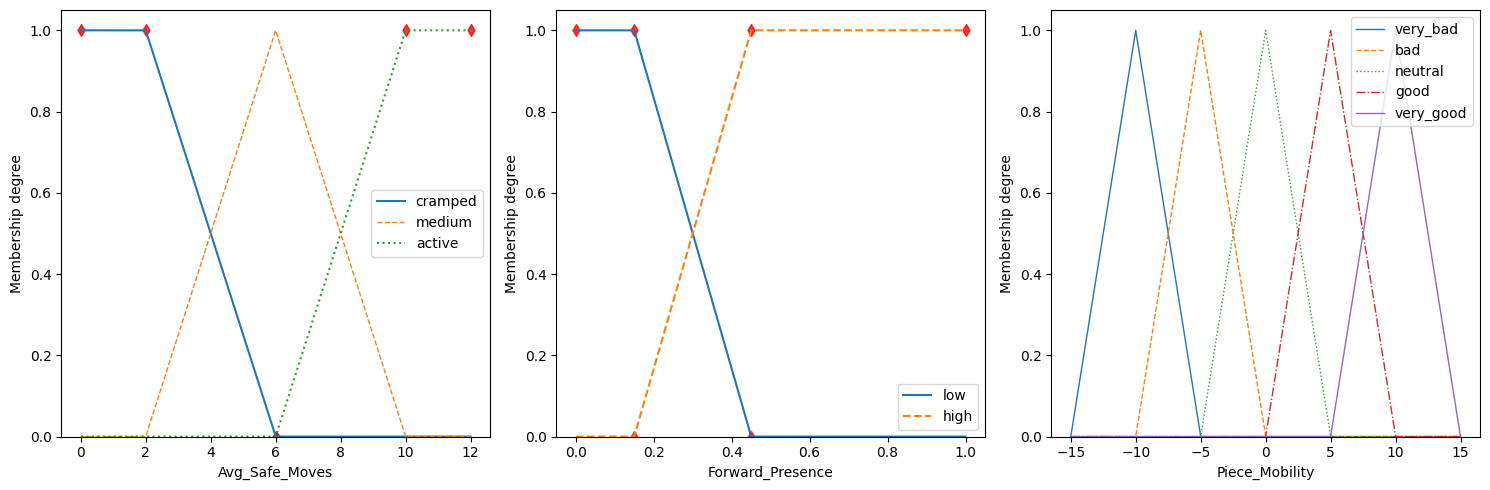

In [9]:
FS.produce_figure()

## Response surface

### Calculations

In [11]:
# Define grid resolution (higher = smoother surface, but slower to compute)
resolution = 20

# Evaluate fuzzy system on a 2D mesh
# Create the 2D meshgrid
x_avg_moves = np.linspace(0, 13, resolution)
y_forward_ratio = np.linspace(0, 1, resolution)
X, Y = np.meshgrid(x_avg_moves, y_forward_ratio)
Z = np.zeros_like(X)

# Evaluate the fuzzy system at each point on the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        FS.set_variable("Avg_Safe_Moves", float(X[i, j]))
        FS.set_variable("Forward_Presence", float(Y[i, j]))
        
        # Run inference
        result = FS.inference()
        Z[i, j] = result["Piece_Mobility"]

### Configure and show plot

In [12]:
# Create the interactive 3D plot with Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=X, 
    y=Y, 
    colorscale='Viridis',
    showscale=False, # Removes the colorbar on the side
    hovertemplate='Avg Safe Moves (X): %{x:.2f}<br>Forward Ratio (Y): %{y:.2f}<br>Mobility Score (Z): %{z:.2f}<extra></extra>'
)])

# Configure layout, titles, camera, and proportions
fig.update_layout(
    title='Central Control Response Surface',
    scene=dict(
        xaxis_title='Avg. Safe Moves',
        yaxis_title='Forward Ratio',
        zaxis_title='Mobility Score',
        aspectmode='cube', # Forces the visual base of the plot to be square
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.2)
        )
    ),
    width=600, 
    height=500,
    margin=dict(l=10, r=0, b=30, t=40) 
)

fig.show()

## Export FIS to lookup table

### Calculate table

In [14]:
# Generate grid
n_pieces = np.arange(0, 7)
total_safe_moves = np.arange(81)
forward_moves = np.arange(50)

mobility_lut = np.zeros((len(n_pieces), len(total_safe_moves), len(forward_moves)))

# Fill table by calculating output for every possible combination
print("Calculating lookup table...")
for i, piece_count in enumerate(n_pieces):
    for j, safe_moves in enumerate(total_safe_moves):
        if piece_count == 0:
            avg_moves = 0.0
        else:
            avg_moves = safe_moves / piece_count
        for k, forward in enumerate(forward_moves):
            if safe_moves == 0:
                forward_presence = 0.0
            else:
                forward_presence = forward / safe_moves
            FS.set_variable("Avg_Safe_Moves", avg_moves)
            FS.set_variable("Forward_Presence", forward_presence)

            result = FS.inference()["Piece_Mobility"]
            mobility_lut[i, j, k] = result

print(f"Lookup table calculated. Shape: {mobility_lut.shape}.")

Calculating lookup table...
Lookup table calculated. Shape: (7, 81, 50).


### Save in file

In [15]:
import os

# Make sure the directory exists
os.makedirs("../data/luts", exist_ok=True)

file_path = "../data/luts/mobility_lut.npy"
np.save(file_path, mobility_lut)

print(f"Successfully saved lookup table as {file_path}.")

Successfully saved lookup table as ../data/luts/mobility_lut.npy.
